### Test for MCMC implementation

In [1]:
import numpy
import random
from matplotlib import pyplot as plt

In [158]:
rng = numpy.random.default_rng(seed=0)

In [159]:
# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

In [160]:
# Generate some synthetic data from the model.
N = 50
xobs = numpy.sort(10 * rng.normal(size=N))
yerr = 0.1 + .5 * rng.normal(size=N)
yobs = m_true * xobs + b_true
yobs += numpy.abs(f_true * yobs) * rng.standard_normal(size=N)
yobs += yerr * rng.standard_normal(size=N)
yerr = numpy.abs(yerr)

## LogLikelihood and Prior

I feel particularly kind today therefore you will not have to implement the log-likelihood and log-prior yourself, do not get used to it.

In [161]:
prior = [
    [-2.0,0.0],
    [2.0,6.0],
    [-4.0, 4.0]
]


In [162]:
def log_likelihood(theta, xx, yy, ee):
    ''' The log-likelihood function for the model.'''
    pass
    if theta.shape != (3,):
        raise ValueError('theta must be a 3-element array: (m, b, log_f)')
    m, b, log_f = theta
    model = m * xx + b
    sigma2 = ee**2 + model**2 * numpy.exp(2 * log_f)
    return -0.5 * numpy.sum((yy - model) ** 2 / sigma2 + numpy.log(sigma2))

In [163]:
def log_prior(theta, prior):
    ''' The log-prior function for the model.'''
    pass
    if theta.shape != (3,):
        raise ValueError('theta must be a 3-element array: (m, b, log_f)')
    
    m, b, log_f = theta
    mlim, blim, flim = prior
    if mlim[0] < m < mlim[1] and blim[0] < b < blim[1] and flim[0] < log_f < flim[1]:
        return 0.0
    return -numpy.inf

In [164]:
def log_posterior(theta, xx, yy, ee, prior):
    ''' The log-posterior function'''
    # require a prior argument
    if prior is None:
        raise ValueError('prior must be supplied')
    lp = log_prior(theta, prior)
    if not numpy.isfinite(lp): # why not just implement it in "else" in prior?
        return -numpy.inf
    return lp + log_likelihood(theta, xx, yy, ee)
    return lp + log_likelihood(theta, xx, yy, ee)

In [165]:
prior = [
    [-2.0,0.0],
    [2.0,6.0],
    [-4.0, 4.0]
]
def starting_point(nwalkers,ndim, prior):
    xstart = []
    for i in range (nwalkers):
        theta = []
        for j in range(ndim):
            theta.append(numpy.random.uniform(prior[j][0],prior[j][1]))
        xstart.append(theta)
    return numpy.array(xstart)

In [182]:
prior = [
    [-2.0,0.0],
    [2.0,6.0],
    [-4.0, 4.0]
]

class MHsampler () :
    
    step = 0.05

    def __init__ ( self, nwalkers, logprob, prior, ndim,  *arg, **kwargs ) :

        if not isinstance(nwalkers, int) or nwalkers <= 0:
            raise ValueError("nwalkers must be a positive integer")
        # initialize the class attributes 
        self.nwalkers = nwalkers
        self.logprob = logprob
        self.prior = prior
        self.ndim = ndim


        # initialize the chain and acceptance fraction
        self.chain = None
        self.lpost = None
        self.accepted = None


    def _initialize_walkers ( self, xstart ) :
        ''' Initialize the walkers. If xstart is None, use last saved position. If xstart is not None, use it as the starting position.'''
        if xstart is None:
            if self.chain is None:
                raise ValueError('xstart must be supplied for the first run')
            else:
                xstart = self.chain[-1]
        elif xstart.shape != (self.nwalkers, self.ndim):
            print(xstart.shape)
            raise ValueError(f'xstart must be of shape ({self.nwalkers}, {self.ndim})')
        return xstart
    
    def _propose ( self, x ) :
        ''' Propose a new position for the walkers.'''
        x_trial = x + type(self).step * rng.standard_normal(size=self.ndim)
        return x_trial
    
    def run ( self, nsteps, xstart=None , *arg, **kwargs ) :
        if self.chain is None:
            self.chain = self._initialize_walkers(xstart)
            self.accepted = 0

        for step in range(nsteps):
            xtrial = self._propose(self.chain[-1])

            # Compute log probabilities for current and proposed positions
            logp_current = self.logprob(self.chain[-1], *arg, **kwargs)
            logp_trial = self.logprob(xtrial, *arg, **kwargs)
            
            # Compute acceptance probability
            log_accept = logp_trial - logp_current
            
            # Generate random numbers for acceptance decisions
            u = numpy.random.uniform(0, 1, size=self.nwalkers)
            
            # Accept or reject each walker
            accept = u < numpy.exp(log_accept)
            
            # Update chain with accepted walkers
            # 'numpy.ndarray' object has no attribute 'append'
            self.chain = numpy.vstack([self.chain, numpy.where(accept[:, None], xtrial, self.chain[-1])])
            #self.chain.append(numpy.where(accept[:, None], xtrial, self.chain[-1]))
            print(f'Step {step+1}/{nsteps}, Acceptance Fraction: {self.acceptance_fraction():.3f}')
            
            # Update acceptance count
            self.accepted += numpy.sum(accept)


    def acceptance_fraction ( self ) :
        if self.chain is None:
            raise ValueError('No samples have been generated yet')
        return self.accepted / len(self.chain)
    
    def get_flat_chain ( self, burnin = 0 ) :
        if self.chain is None:
            raise ValueError('No samples have been generated yet')
        return self.chain[burnin:].reshape(-1, self.ndim)

In [203]:
nwalkers = 10
ndim = 3

x_ini = starting_point(nwalkers, ndim, prior)
sampler = MHsampler(nwalkers, log_posterior, prior, ndim)
sampler.run(10000, xstart=x_ini, xx= xobs, yy=yobs, ee=yerr, prior=prior)

sampler.get_flat_chain()


Step 1/10000, Acceptance Fraction: 0.000
Step 2/10000, Acceptance Fraction: 0.333
Step 3/10000, Acceptance Fraction: 0.500
Step 4/10000, Acceptance Fraction: 0.600
Step 5/10000, Acceptance Fraction: 0.517
Step 6/10000, Acceptance Fraction: 0.586
Step 7/10000, Acceptance Fraction: 0.637
Step 8/10000, Acceptance Fraction: 0.678
Step 9/10000, Acceptance Fraction: 0.610
Step 10/10000, Acceptance Fraction: 0.645
Step 11/10000, Acceptance Fraction: 0.592
Step 12/10000, Acceptance Fraction: 0.546
Step 13/10000, Acceptance Fraction: 0.514
Step 14/10000, Acceptance Fraction: 0.547
Step 15/10000, Acceptance Fraction: 0.575
Step 16/10000, Acceptance Fraction: 0.600
Step 17/10000, Acceptance Fraction: 0.567
Step 18/10000, Acceptance Fraction: 0.589
Step 19/10000, Acceptance Fraction: 0.610
Step 20/10000, Acceptance Fraction: 0.624
Step 21/10000, Acceptance Fraction: 0.641
Step 22/10000, Acceptance Fraction: 0.657
Step 23/10000, Acceptance Fraction: 0.671
Step 24/10000, Acceptance Fraction: 0.684
S

array([[-1.20167288,  4.8262902 , -2.9453754 ],
       [-0.72245518,  2.82199053,  3.38918178],
       [-1.46940914,  3.86708135, -0.95264646],
       ...,
       [-0.95287383,  4.33985328, -0.72410002],
       [-0.95287383,  4.33985328, -0.72410002],
       [-0.95287383,  4.33985328, -0.72410002]], shape=(100010, 3))

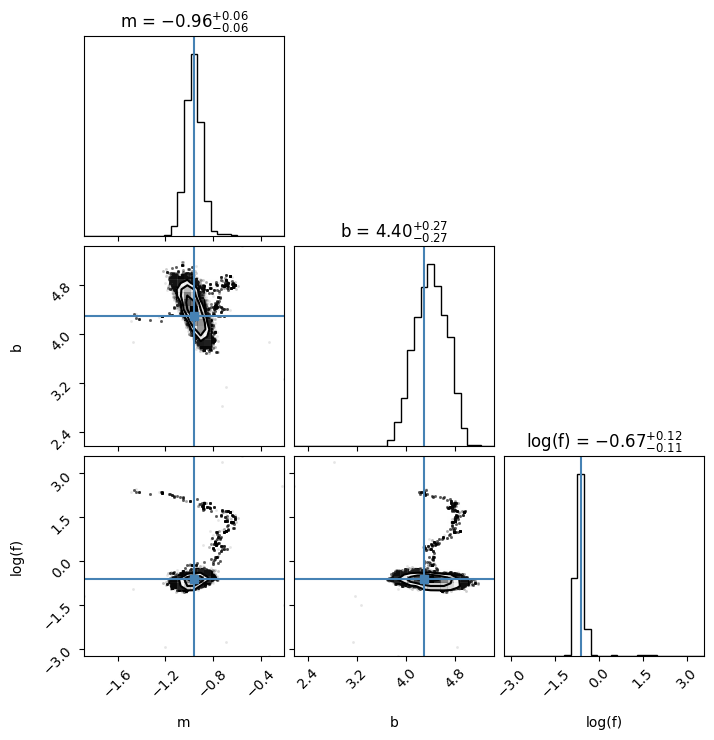

In [205]:
outchain = sampler.get_flat_chain()
import corner
fig = corner.corner(
    outchain, labels = ["m", "b", "log(f)"], truths = [m_true, b_true, numpy.log(f_true)], bins=30, show_titles=True, title_fmt=".2f"
)

In [206]:
# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

In [ ]:
numpy.random.choiche() # This is a test of the random choice functiona